# model training small dataset STL-10
- traditional
    > feature exraction
    - SIFT/HOG
    > model
    - Knn
    - SVM
    - decision Tree
- DL
    - ResNet18

### Step 1 - import all the lib

In [4]:
# training lib

# extraction lib

#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
from sklearn.model_selection import train_test_split
# KNN classifier
from sklearn.neighbors import KNeighborsClassifier
# DT classifier
from sklearn.tree import DecisionTreeClassifier
# SGD classifier
from sklearn.linear_model import SGDClassifier
# comprision display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    )
from download import read_all_images, read_labels


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sys.version_info(major=3, minor=11, micro=14, releaselevel='final', serial=0)


### Step 2 - define path

In [5]:
from pathlib import Path
import os
result_dir = Path("/result")
# model_dir = result_dir / "model"
# analysis_dir = result_dir / "analysis"
# result/svmmodel1/model, result
#data_set_dir = Path("/data_set")
img_dir = Path("/img")


### Step 3 Fetch data

In [6]:
# fetch training znd valid data how to do this

# we dont need to use the split do we?
# Extract 300 for each type

# after extract show the image
train_images = read_all_images(
    "./data/stl10_binary/train_X.bin"
)
train_labels = read_labels(
    "./data/stl10_binary/train_y.bin"
)

test_images = read_all_images(
    "./data/stl10_binary/test_X.bin"
)
test_labels = read_labels(
    "./data/stl10_binary/test_y.bin"
)

print(train_images.shape)  # (5000, 96, 96, 3)
print(train_labels.shape)  # (5000,)

print(test_images.shape)   # (8000, 96, 96, 3)
print(test_labels.shape)   # (8000,)



(5000, 96, 96, 3)
(5000,)
(8000, 96, 96, 3)
(8000,)


- Display and extract 5 classes, 300 for trainingm 100 and 100 for val and test

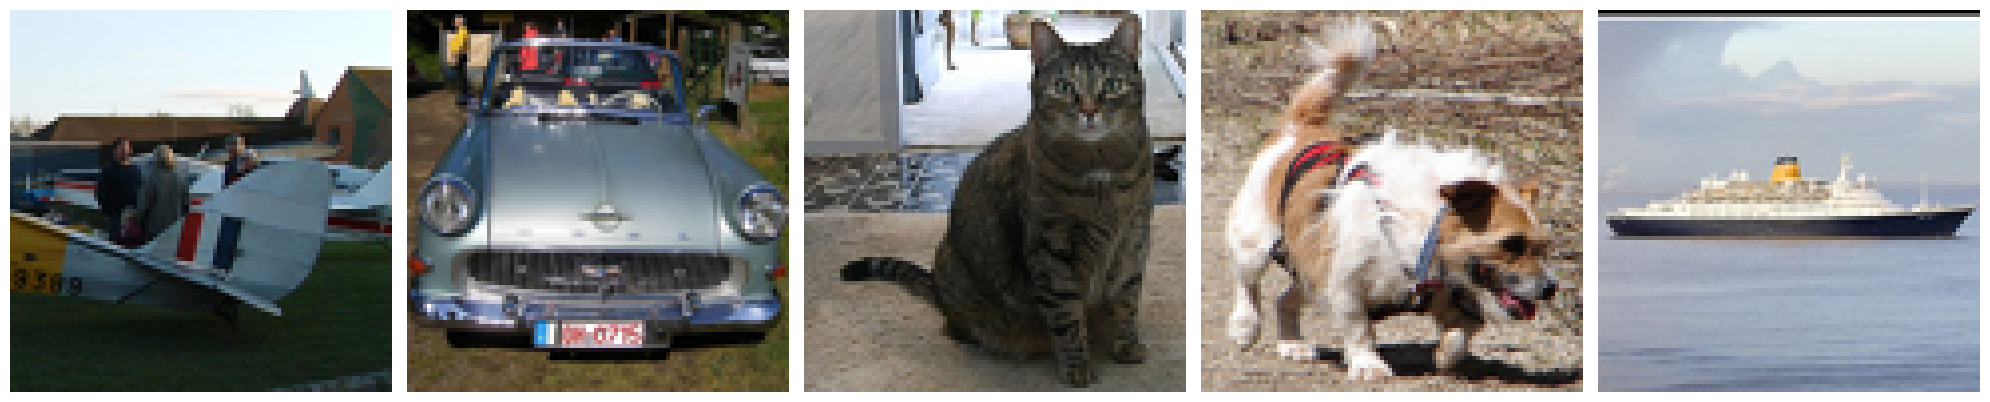

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(20, 7))
axes = axes.ravel()
# select label
#airplane car cat dog ship
selected_label = [1, 3, 4, 6, 9]

mask = np.isin(train_labels, selected_label)
selected_train_X = train_images[mask]
selected_train_y = train_labels[mask]

mask = np.isin(test_labels, selected_label)
selected_test_X = test_images[mask]
selected_test_y = test_labels[mask]

selected_train_indices = []
selected_val_indices = []
selected_test_indices = []

i = 0
for n in selected_label:

    idx = np.where(selected_train_y == n)[0]# retun nparray
    # get 300 for training
    chosen = np.random.choice(idx, size=300, replace=False)# replace off means same value wont be chose many times

    axes[i].imshow(selected_train_X[chosen[0]])
    axes[i].axis("off")
    selected_train_indices.extend(chosen)
    # get 100 for val
    chosen = np.random.choice(idx, size=100, replace=False)# replace off means same value wont be chose many times
    selected_val_indices.extend(chosen)# append then [s1. s2, s3] //// extend [s1 s2 s3 ]

    # fet 100 for test
    idx = np.where(selected_test_y == n)[0]
    chosen = np.random.choice(idx, size=100, replace=False)# replace off means same value wont be chose many times
    selected_test_indices.extend(chosen)# append then [s1. s2, s3] //// extend [s1 s2 s3 ]
    i = i + 1


plt.tight_layout()
plt.show()

selected_train_indices = np.array(selected_train_indices)
selected_val_indices = np.array(selected_val_indices)
selected_test_indices = np.array(selected_test_indices)

# selected_label = [1, 3, 4, 6, 9]

train_X = selected_train_X[selected_train_indices]
train_y = selected_train_y[selected_train_indices]

val_X = selected_train_X[selected_val_indices]
val_y = selected_train_y[selected_val_indices]

test_X = selected_test_X[selected_test_indices]
test_y = selected_test_y[selected_test_indices]

# # change label to 0-4
# for label in train_y, val_y, test_y:
    # it is changing temp var
#     result = []
#     for i in label:
#         if i == 1:
#             result.append(0)
#         elif i == 3:
#             result.append(1)
#         elif i == 4:
#             result.append(2)
#         elif i == 6:
#             result.append(3)
#         else:
#             result.append(4)
#     label = np.array(result)
#     print(label.shape)

- label mapping

In [15]:
label_mapping = {
    1: 0,
    3: 1,
    4: 2,
    6: 3,
    9: 4
}

def remap(labels):
    return np.array(
        [label_mapping[int(label)] for label in labels],
        # why int64?
        dtype=np.int64
    )
# print(type(train_y[0]))
train_y = remap(train_y)
# print(type(train_y[0]))
test_y = remap(test_y)
val_y = remap(val_y)
    # it is changing temp var
print(np.unique(train_y, return_counts=True))

(array([0, 1, 2, 3, 4]), array([300, 300, 300, 300, 300]))


- ImageNet standard normalization

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    )
])

val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])
train_transform(train_X);

In [8]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights


- support gpu training

In [9]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

mps


In [ ]:

model = resnet18(
    # pre-trained model
    weights=ResNet18_Weights.DEFAULT
)

model.fc = nn.Linear(
    model.fc.in_features,
    5
)